# Лекция 2. Ценность действия и уравнение Беллмана

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/IlyaChichkanov/Reinforcement-learning/blob/main/02-environments/lecture/lecture.ipynb)

**Главный вопрос сегодня: как выбрать действие сейчас, если награда придёт потом?**

На прошлой лекции мы искали хорошую стратегию перебором: играли сотни эпизодов, отбирали удачные, повторяли их действия. Сегодня научимся **считать**, насколько хорош каждый шаг, — и стратегия получится из этих чисел сама. Числа называются ценностью, а считает их уравнение Беллмана: одно уравнение, на котором стоит весь остальной курс.

Путь лекции — два шага:

1. **Оценки.** Если бы кто-то дал нам таблицу «насколько хорошо сделать это действие в этой клетке», стратегия получалась бы даром.
2. **Уравнение.** Эти оценки связаны друг с другом уравнением Беллмана, и из него их можно вычислить — точно и без единого сыгранного эпизода.

А что делать, когда устройство среды неизвестно и вычислять не из чего, — тема недели 3.

| | Раздел | Минут |
|---|---|---|
| 1 | Где мы остановились | 6 |
| 2 | Мир, на котором всё посчитаем | 11 |
| 3 | Если бы у нас были оценки: $Q^\pi$, $Q^*$ и $V$ | 19 |
| 4 | Уравнение Беллмана | 21 |
| 5 | Ещё один пример: Колобок и лотерея | 6 |
| 6 | Это называется MDP | 9 |
| 7 | Как оценить стратегию и как её улучшить | 12 |
| 8 | Итоги | 6 |

Изложение следует главе [«Обучение с подкреплением»](https://education.yandex.ru/handbook/ml/article/obuchenie-s-podkrepleniem) Учебника по машинному обучению ШАД: оттуда взяты и ход рассуждений, и примеры (клетчатый мир, Колобок с лотереей). Служебный код вынесен в файлы `gridworld.py` и `gridworld_plots.py` рядом с ноутбуком — читать их не нужно. Пометка **⏱** — резерв, если останется время.

In [1]:
# В Google Colab: скачиваем два служебных файла лекции. Локально (файлы лежат рядом) ячейка ничего не делает.
import pathlib, urllib.request
for name in ["gridworld.py", "gridworld_plots.py"]:
    if not pathlib.Path(name).exists():
        urllib.request.urlretrieve("https://raw.githubusercontent.com/IlyaChichkanov/Reinforcement-learning/main/02-environments/lecture/" + name, name)

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from gridworld import *          # GridWorld, mdp_matrices, run_episode, average_return, solve_q_star, greedy_policy, GAMMA
from gridworld_plots import *    # draw_grid, plot_values, plot_q, draw_policy, draw_transitions, draw_paths, draw_backup

env = GridWorld()                # мир из раздела 2
P, R = mdp_matrices(env)         # модель среды: P[s, a, s'] и средняя награда R[s, a]
Q_star = solve_q_star(P, R)      # «ответ» для раздела 3; как он считается — раздел 4
V_star = Q_star.max(axis=1)
print(f"клеток: {env.n_states}, действий: {env.n_actions}, дисконт γ = {GAMMA}")

клеток: 12, действий: 4, дисконт γ = 0.95


## 1. Где мы остановились

В лекции 1 мы написали первый алгоритм RL — метод Cross-Entropy: сыграть 200 эпизодов, отобрать лучшие 30%, повторять действия из них, и так 25 раз. Работает, но посмотрите, **чем** он пользуется.

![мост](https://raw.githubusercontent.com/IlyaChichkanov/Reinforcement-learning/main/assets/from_episodes_to_steps.png)

Cross-Entropy видит только **итог эпизода**: одно число на сотню шагов. Агент мог сделать 99 правильных шагов и один раз оступиться — эпизод уйдёт в мусор целиком, вместе с 99 правильными шагами. А в большой среде удачные эпизоды вообще почти не встречаются, и отбирать нечего.

Хочется другого: оценки **на каждый шаг** — «насколько хорошо сделать вот это действие вот в этой клетке». Тогда учиться можно с каждого шага, а не с каждого эпизода. Вся сегодняшняя лекция — про то, откуда такие оценки берутся.

## 2. Мир, на котором всё посчитаем

Frozen Lake из прошлой лекции мы отложим: там агента сносит в две стороны из трёх, и рассуждать о числах тяжело. Возьмём мир попроще — тот самый клетчатый мир, который мелькал в лекции 1 (он же стандартный пример из учебника ШАД).

![правила](https://raw.githubusercontent.com/IlyaChichkanov/Reinforcement-learning/main/assets/gridworld_rules.png)

Правила целиком:

* агент стоит в одной из **12 клеток** (клетка 5 — стена, туда нельзя);
* на каждом шаге выбирает одно из **четырёх действий** — попытку шагнуть влево, вниз, вправо или вверх;
* **ветер**: с вероятностью 0.8 агент идёт куда просил, с вероятностью 0.1 его сносит в каждую из двух боковых сторон; шаг в стену или за край оставляет его на месте;
* **награда**: −0.04 за каждый шаг (время дорого, гулять вечно невыгодно), +1 за вход в зелёную клетку, −1 за вход в красную;
* попав в зелёную или красную клетку, агент останавливается — **эпизод закончен**.

Ветер — единственное, что делает задачу интересной: намерение и результат не совпадают. Посмотрим на него.

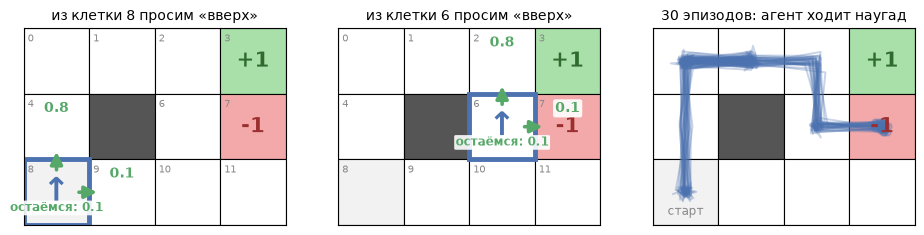

средний return случайной стратегии: -0.67


In [3]:
fig, axes = plt.subplots(1, 3, figsize=(11.5, 3.5))
draw_transitions(env, s=8, a=3, ax=axes[0])     # из старта просим «вверх»
draw_transitions(env, s=6, a=3, ax=axes[1])     # а здесь ветер может занести в яму
draw_paths([run_episode(env, uniform_policy(env), np.random.default_rng(0)) for _ in range(30)], env,
           ax=axes[2], title="30 эпизодов: агент ходит наугад")
plt.show()

rng = np.random.default_rng(0)
print(f"средний return случайной стратегии: {average_return(env, uniform_policy(env), rng):+.2f}")

Слева: попросили «вверх» из старта — с вероятностью 0.8 поднялись, по 0.1 остались на месте (слева стена мира) или уехали вправо. В середине: из клетки 6 то же действие с вероятностью 0.1 заносит **в яму**. Справа: агент, который ходит наугад, бродит по всему полю и часто заканчивает в красной клетке; в среднем он получает около −0.7.

Всё, что дальше, — попытка выбрать действия лучше, чем наугад. Заметьте: никакой новой математики пока не появилось, только правила игры.

### 2.1 Правила в виде двух таблиц

Всё, что нарисовано выше, можно записать двумя массивами — это и называется **моделью среды**. Она понадобится нам в разделе 4, поэтому посмотрим на неё сейчас.

* $p(s' \mid s, a)$ — вероятность оказаться в клетке $s'$, если в клетке $s$ выбрать действие $a$. В коде это `P[s, a, s_next]`: таблица на 12 клеток × 4 действия × 12 клеток.
* $r(s, a)$ — средняя награда за один такой шаг. В коде это `R[s, a]`: 12 клеток × 4 действия.

Строка `P[8, ↑]` — это буквально левая картинка выше: три ненулевых числа, 0.8 и два раза по 0.1.

In [4]:
print("форма P:", P.shape, " — вероятности: клетка × действие × следующая клетка")
print("форма R:", R.shape, "    — средняя награда за шаг: клетка × действие")

print("\nP[8, ↑] — куда ведёт «вверх» из старта (только ненулевые):")
for s_next in np.flatnonzero(P[8, 3]):
    print(f"   в клетку {s_next}: вероятность {P[8, 3, s_next]:.1f}")
print(f"R[8, ↑] = {R[8, 3]:+.2f} — плата за шаг; награды ±1 попадут в R только у клеток рядом с выходом и ямой")
print(f"каждая строка — распределение, сумма вероятностей равна 1: {P.sum(axis=2).round(6).min()}")

форма P: (12, 4, 12)  — вероятности: клетка × действие × следующая клетка
форма R: (12, 4)     — средняя награда за шаг: клетка × действие

P[8, ↑] — куда ведёт «вверх» из старта (только ненулевые):
   в клетку 4: вероятность 0.8
   в клетку 8: вероятность 0.1
   в клетку 9: вероятность 0.1
R[8, ↑] = -0.04 — плата за шаг; награды ±1 попадут в R только у клеток рядом с выходом и ямой
каждая строка — распределение, сумма вероятностей равна 1: 1.0


Две таблицы — это **вся** среда: имея их, можно ответить на любой вопрос о будущем, ни разу не запустив `env.step`. Именно этим мы и займёмся в разделе 4. (А что делать, когда таких таблиц нет, — тема недели 3.)

## 3. Если бы у нас были оценки

Представьте, что для каждой клетки и каждого действия у нас есть число — **сколько в среднем удастся собрать дальше**. Тогда стратегия получается даром: в клетке сравнить четыре числа и выбрать наибольшее. Ровно такие числа мы и будем считать всю оставшуюся лекцию.

Но в словах «сколько соберём дальше» спрятан вопрос: **дальше — это как?** Пойдём напролом мимо ямы или в обход? Число зависит от того, как мы собираемся играть, то есть от стратегии. Поэтому сначала определим ценность для **произвольной** стратегии, а лучшая получится из неё частным случаем.

### 3.1 Ценность заданной стратегии

Пусть стратегия $\pi$ зафиксирована — хоть «бросаю кубик», хоть «всегда вверх». С ней связаны две величины:

* $V^\pi(s)$ — **ценность состояния**: сколько в среднем соберём, начав в клетке $s$ и дальше действуя по $\pi$;
* $Q^\pi(s, a)$ — **ценность действия**: то же самое, но первый ход делаем сами — действие $a$, — а по $\pi$ играем со следующего шага.

$$
V^\pi(s) = \mathbb E_\pi\Big[\, \sum_{t \ge 0} \gamma^t r_t \;\Big|\; s_0 = s \,\Big],
\qquad
Q^\pi(s, a) = \mathbb E_\pi\Big[\, \sum_{t \ge 0} \gamma^t r_t \;\Big|\; s_0 = s,\; a_0 = a \,\Big].
$$

Под матожиданием — тот самый дисконтированный return из лекции 1, а усреднение идёт по двум источникам случайности: по выбору действий стратегией и по ответам среды. Отличаются $V^\pi$ и $Q^\pi$ только моментом, в который мы смотрим: у $V^\pi$ действие ещё не выбрано, у $Q^\pi$ уже выбрано и мы ждём, что сделает ветер. А эти моменты идут друг за другом — ходы чередуются.

![связь V и Q](https://raw.githubusercontent.com/IlyaChichkanov/Reinforcement-learning/main/assets/v_q_link.png)

**Ход агента.** В клетке $s$ действие выбирает стратегия: с вероятностью $\pi(a \mid s)$ будет выбрано $a$. Значит, ценность клетки — среднее ценностей действий с весами $\pi$:

$$
V^\pi(s) \;=\; \sum_a \pi(a \mid s)\, Q^\pi(s, a).
$$

**Ход среды.** Действие выбрано, и дальше решаем не мы: ветер разводит нас по клеткам $s'$ с вероятностями $p(s' \mid s, a)$. Значит, усредняем по исходам — прибавив награду за сам шаг и обесценив будущее на $\gamma$:

$$
Q^\pi(s, a) \;=\; \sum_{s'} p(s' \mid s, a)\,\big[\, r + \gamma\, V^\pi(s') \,\big].
$$

Ни то, ни другое не требует доказательства: ценность — это среднее, а среднее по всей случайности сразу можно считать в два приёма, сначала по выбору действия, потом по ответу среды. Для детерминированной стратегии первая сумма и вовсе состоит из одного слагаемого: $V^\pi(s) = Q^\pi(s, \pi(s))$.

### 3.2 Лучшая стратегия

Стратегий много, а нужна лучшая. Обозначим лучшее, чего вообще можно добиться:

$$
Q^*(s, a) = \max_\pi Q^\pi(s, a), \qquad V^*(s) = \max_\pi V^\pi(s).
$$

Словами: $Q^*(s, a)$ — сколько максимально можно собрать, сделав в клетке $s$ действие $a$ и дальше играя как можно лучше. Определение неконструктивное — перебрать все стратегии мы не можем, — но у него есть замечательное свойство: **если $Q^*$ известна, то известна и оптимальная стратегия**. Стоя в клетке, мы знаем, что первое действие принесёт не больше $Q^*(s, a_1)$, второе — не больше $Q^*(s, a_2)$, и так далее. Значит, надо выбрать действие с наибольшим числом.

![выбор](https://raw.githubusercontent.com/IlyaChichkanov/Reinforcement-learning/main/assets/q_choice.png)

Такой выбор называется **жадным** (greedy) по отношению к $Q^*$, а утверждение «жадный выбор по оптимальной Q-функции оптимален» — **принципом оптимальности Беллмана**. Звучит как тавтология, но содержание в нём есть: оптимальная стратегия оказывается **детерминированной** (никакой случайности) и **не зависит от времени** — в одной и той же клетке всегда одно и то же действие, сколько бы шагов ни прошло.

Отсюда сразу получаются связи для оптимальных величин — это те же две связи из 3.1, просто подставлена оптимальная стратегия. Жадная $\pi^*$ кладёт всю вероятность на лучшее действие, поэтому усреднение по $\pi$ в первой связи превращается в максимум:

![схлопывание](https://raw.githubusercontent.com/IlyaChichkanov/Reinforcement-learning/main/assets/pi_star_collapse.png)

$$
V^*(s) \;=\; \sum_a \pi^*(a \mid s)\, Q^*(s, a) \;=\; \max_a Q^*(s, a).
$$

А вторая связь не меняется вовсе: ветер работает одинаково, какой бы стратегии мы ни придерживались, —

$$
Q^*(s, a) \;=\; \sum_{s'} p(s' \mid s, a)\,\big[\, r + \gamma\, V^*(s') \,\big].
$$

Посмотрим на таблицу $Q^*$ для нашего мира. Откуда она взялась — следующий раздел; сейчас важно, что из неё получается.

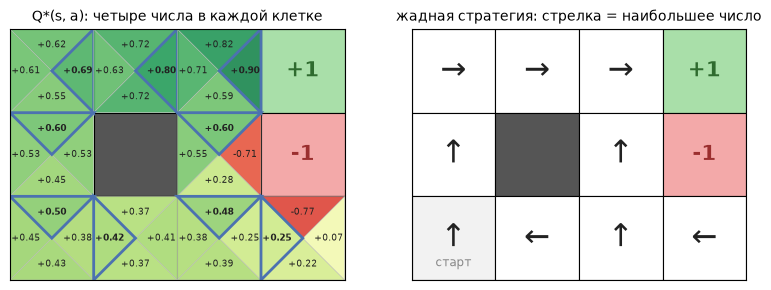

средний return: жадная стратегия +0.51, случайная -0.67


In [5]:
pi_star = greedy_policy(Q_star)                  # в каждой клетке: argmax_a Q*(s, a)

fig, axes = plt.subplots(1, 2, figsize=(9.5, 3.6))
plot_q(Q_star, env, ax=axes[0], title="Q*(s, a): четыре числа в каждой клетке")
draw_policy(pi_star, env, ax=axes[1], title="жадная стратегия: стрелка = наибольшее число")
plt.show()

rng = np.random.default_rng(0)
print(f"средний return: жадная стратегия {average_return(env, pi_star, rng):+.2f}, "
      f"случайная {average_return(env, uniform_policy(env), rng):+.2f}")

Разница огромная: $+0.5$ против $-0.7$. И обратите внимание на клетку 9 (нижний ряд, вторая): жадная стрелка ведёт **влево**, в сторону от выхода. Агент идёт длинным путём вдоль левого края, лишь бы не проходить под ямой, где ветер может его туда сдуть. Это не эвристика, которую кто-то придумал, — это следствие чисел.

Теперь практическая разница между $V$ и $Q$ — она важнее формальной.

![V и Q](https://raw.githubusercontent.com/IlyaChichkanov/Reinforcement-learning/main/assets/v_vs_q.png)

* $V(s)$ — **одно** число на клетку: «насколько хорошо здесь оказаться».
* $Q(s, a)$ — **четыре** числа на клетку (по одному на действие): «насколько хорошо отсюда сделать вот это».
* Из $Q$ стратегия достаётся мгновенно: сравни четыре числа и выбери наибольшее. Из $V$ — **нет**: чтобы понять, какое действие ведёт в хорошую клетку, нужна вторая связь, а в ней сидит модель среды $p(s' \mid s, a)$. Поэтому алгоритмы, которые учатся без модели (Q-learning, DQN), учат именно $Q$.

Осталось главное: ни одна из связей сама по себе ничего не считает — в правой части каждой стоит **другая** неизвестная функция. Что с этим делать — следующий раздел.

## 4. Уравнение Беллмана

Две связи из прошлого раздела по отдельности ничего не дают: каждая выражает одну неизвестную функцию через другую. Но в такой ситуации напрашивается подстановка — вставим одну связь в правую часть другой, и функция окажется выражена через себя же.

Почему это законно — вот ключевое наблюдение, из которого вырастает весь курс. Мы сделали действие $a$, получили награду и оказались в клетке $s'$ — и **из $s'$ нас ждёт ровно такая же задача**, только из другой клетки. Правила мира не изменились, а как именно мы в $s'$ попали, ни на что не влияет. Поэтому в правой части стоит **та же самая** функция, а не какая-то новая «ценность на втором шаге».

![подстановка](https://raw.githubusercontent.com/IlyaChichkanov/Reinforcement-learning/main/assets/bellman_substitution.png)

**Сначала для произвольной стратегии.** Подставим связь 1 в связь 2 — вместо $V^\pi(s')$ напишем $\sum_{a'} \pi(a' \mid s')\, Q^\pi(s', a')$:

$$
Q^\pi(s, a) \;=\; \sum_{s'} p(s' \mid s, a)\,\Big[\, r + \gamma \sum_{a'} \pi(a' \mid s')\, Q^\pi(s', a') \,\Big]
$$

Это **уравнение Беллмана для стратегии $\pi$**. Подстановка в другую сторону даёт уравнение на $V^\pi$: $V^\pi(s) = \sum_a \pi(a \mid s) \sum_{s'} p(s' \mid s, a)\,[\, r + \gamma V^\pi(s') \,]$. Оно отвечает на вопрос «насколько хороша вот эта стратегия» — этим мы займёмся в разделе 7.

**Теперь для оптимальной.** Всё то же самое, только усреднение по $\pi^*$ схлопывается в максимум (раздел 3.2):

$$
\boxed{\;Q^*(s, a) \;=\; \sum_{s'} p(s' \mid s, a)\,\Big[\, r + \gamma \max_{a'} Q^*(s', a') \,\Big]\;}
$$

$$
\boxed{\;V^*(s) \;=\; \max_a \sum_{s'} p(s' \mid s, a)\,\Big[\, r + \gamma\, V^*(s') \,\Big]\;}
$$

Это **уравнения оптимальности Беллмана**. Отличие от уравнения для $\pi$ ровно одно: там, где стояло усреднение $\sum_{a'} \pi(a' \mid s')$, стоит $\max_{a'}$. Дальше мы работаем с уравнением на $Q^*$: из $Q^*$ стратегия достаётся сравнением четырёх чисел, а из $V^*$ — только вместе с моделью.

📖 Сумму по исходам обычно сокращают до матожидания, и тогда уравнение выглядит так, как вы встретите его в учебниках: $Q^*(s, a) = \mathbb E_{s'}\big[\, r + \gamma \max_{a'} Q^*(s', a') \,\big]$.

Прежде чем решать уравнение, убедимся, что правую часть мы умеем считать. Распишем её руками для двух действий из старта.

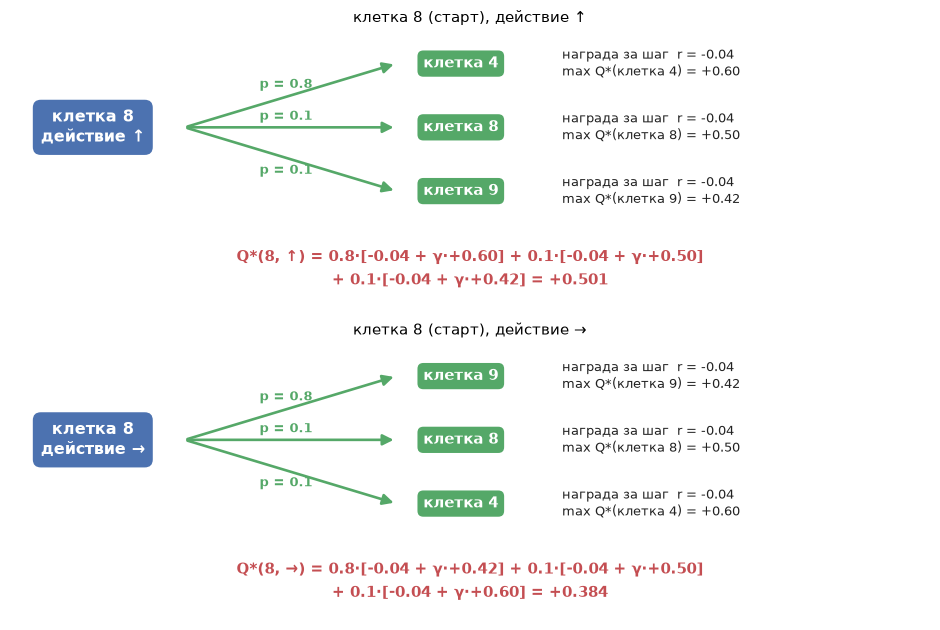

а вот те же числа из таблицы: Q*(8, ↑) = +0.501,  Q*(8, →) = +0.384


In [6]:
def outcomes(s, a):                              # исходы одного действия: (вероятность, куда, награда, ценность той клетки)
    return [(prob, s_next, reward, V_star[s_next]) for prob, s_next, reward, _ in env.transitions(s, a)]

fig, axes = plt.subplots(2, 1, figsize=(9.5, 6.4))
draw_backup(env, 8, 3, outcomes(8, 3), GAMMA, ax=axes[0], title="клетка 8 (старт), действие ↑")
draw_backup(env, 8, 2, outcomes(8, 2), GAMMA, ax=axes[1], title="клетка 8 (старт), действие →")
plt.tight_layout(); plt.show()

print(f"а вот те же числа из таблицы: Q*(8, ↑) = {Q_star[8, 3]:+.3f},  Q*(8, →) = {Q_star[8, 2]:+.3f}")

Арифметика «на один шаг вперёд» дала ровно те числа, что стоят в таблице $Q^*$. Считали мы при этом связь 2 из раздела 3: награда за шаг плюс усреднённые по вероятностям ценности соседних клеток, обесцененные на $\gamma$. И сразу видно, почему из старта выгоднее вверх, чем вправо: оба действия стоят −0.04, но «вверх» с вероятностью 0.8 приводит в клетку ценности $+0.60$, а «вправо» — в клетку ценности $+0.42$.

Особенность уравнения в том, что неизвестная функция стоит **по обе стороны**. Для нашего мира это система из $12 \times 4 = 48$ уравнений с 48 неизвестными. Система нелинейная (из-за максимума), но у неё есть единственное решение, и его можно найти **методом простой итерации**: взять любое начальное приближение, подставить его в правую часть, получить новое — и так до сходимости.

> Если у нас есть какое-то приближение $Q$, то вычисление правой части уравнения даёт приближение **лучше**. Это единственное, что нужно запомнить из раздела.

### 4.1 Что именно считает одна итерация

Распишем правую часть без сокращений, через таблицы из раздела 2.1. Пусть $Q_k$ — текущее приближение. Тогда следующее получается так:

$$
V_k(s') = \max_{a'} Q_k(s', a'), \qquad
Q_{k+1}(s, a) = r(s, a) + \gamma \sum_{s'} p(s' \mid s, a)\, V_k(s').
$$

Словами, по шагам:

1. для каждой клетки $s'$ берём **лучшее** число в её строке — это $V_k(s')$, «сколько обещает текущее приближение из этой клетки»;
2. для пары $(s, a)$ смотрим, куда среда может нас увести, и усредняем эти обещания с весами-вероятностями;
3. прибавляем награду за сам шаг и умножаем будущее на $\gamma$.

Пункт 2 — это обычное скалярное произведение строки вероятностей на вектор ценностей, поэтому весь пересчёт записывается одной строкой numpy.

![итерация](https://raw.githubusercontent.com/IlyaChichkanov/Reinforcement-learning/main/assets/vi_update.png)

Сначала напишем ту же формулу дословно, тремя циклами, — так видно, что никакой магии нет.

In [7]:
def bellman_update_loops(Q):
    """Одна итерация уравнения Беллмана, записанная дословно по формуле."""
    V = Q.max(axis=1)                                        # шаг 1: лучшее число в строке каждой клетки
    Q_new = np.zeros_like(Q)
    for s in range(env.n_states):                            # по всем клеткам
        for a in range(env.n_actions):                       # по всем действиям
            future = 0.0
            for s_next in range(env.n_states):               # шаг 2: усредняем по исходам ветра
                future += P[s, a, s_next] * V[s_next]
            Q_new[s, a] = R[s, a] + GAMMA * future           # шаг 3: награда за шаг + дисконтированное будущее
    return Q_new

Q_zero = np.zeros((env.n_states, env.n_actions))
print("после одной итерации из нулей, клетка 2 (рядом с выходом):", bellman_update_loops(Q_zero)[2].round(2))
print("та же итерация одной строкой numpy:                       ",
      (R + GAMMA * (P @ Q_zero.max(axis=1)))[2].round(2))
assert np.allclose(bellman_update_loops(Q_zero), R + GAMMA * (P @ Q_zero.max(axis=1)))

после одной итерации из нулей, клетка 2 (рядом с выходом): [-0.04  0.06  0.76  0.06]
та же итерация одной строкой numpy:                        [-0.04  0.06  0.76  0.06]


Три вложенных цикла — это $12 \times 4 = 48$ чисел, каждое из которых сумма из 12 слагаемых. Векторная запись `R + GAMMA * (P @ V)` делает ровно это, только сразу для всех пар: `P @ V` перемножает и складывает за нас.

### 4.2 Повторяем до сходимости

Теперь сам алгоритм: начинаем с нулей и подставляем приближение в правую часть, пока оно не перестанет меняться. «Перестало меняться» означает, что наибольшая поправка стала меньше `tol`; тогда левая и правая части уравнения совпали, а значит, мы нашли его решение. Алгоритм называется **value iteration**.

In [8]:
Q = np.zeros((env.n_states, env.n_actions))      # начальное приближение: сплошные нули
history = [Q]                                    # history[k] — приближение после k итераций, для картинки ниже

for k in range(1, 500):
    V = Q.max(axis=1)                            # (12,)   лучшее, что обещает текущее приближение в каждой клетке
    Q_new = R + GAMMA * (P @ V)                  # (12, 4) правая часть уравнения сразу для всех пар (s, a)
    history.append(Q_new)
    if np.abs(Q_new - Q).max() < 1e-10:          # приближение перестало меняться — уравнение решено
        break
    Q = Q_new

print(f"сошлось за {k} итераций; совпадает с таблицей из раздела 3: {np.allclose(Q, Q_star)}")

сошлось за 37 итераций; совпадает с таблицей из раздела 3: True


Посмотрим на приближения по дороге: `history[k]` — это таблица после $k$ итераций, а на картинке для каждой клетки показано лучшее её число, то есть $V_k$.

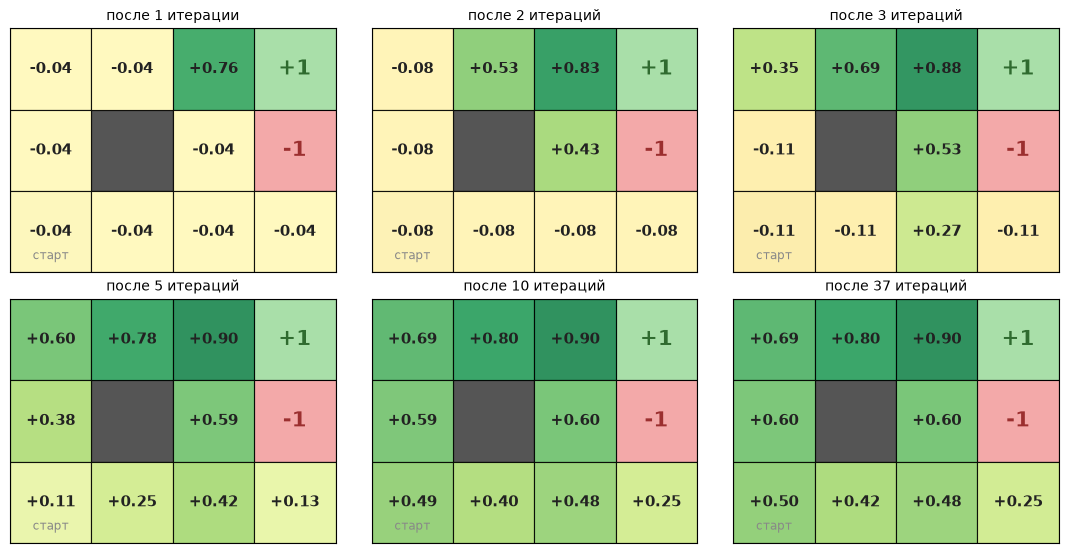

In [9]:
fig, axes = plt.subplots(2, 3, figsize=(11, 5.6))
for ax, k in zip(axes.ravel(), [1, 2, 3, 5, 10, len(history) - 1]):
    plot_values(history[k].max(axis=1), env, ax=ax,
                title="после 1 итерации" if k == 1 else f"после {k} итераций")
plt.tight_layout(); plt.show()

Посмотрите, как считаются числа. После первой итерации ненулевые оценки есть только рядом с выходом: остальные клетки «не знают» ни про +1, ни про −1, у них только −0.04 за шаг. Каждая следующая итерация продвигает информацию ещё на одну клетку — знание о награде расходится от выхода волной и через десяток итераций накрывает всё поле.

Полезная деталь: ценность падает по мере удаления от выхода не только из-за платы за шаги, но и потому, что дальний путь — это больше шансов, что ветер снесёт куда-то не туда.

**⏱ Зачем вообще считать, если стрелки можно расставить руками?** Потому что ответ зависит от условий задачи так, что угадать его нельзя. Изменим только одно число — плату за шаг.

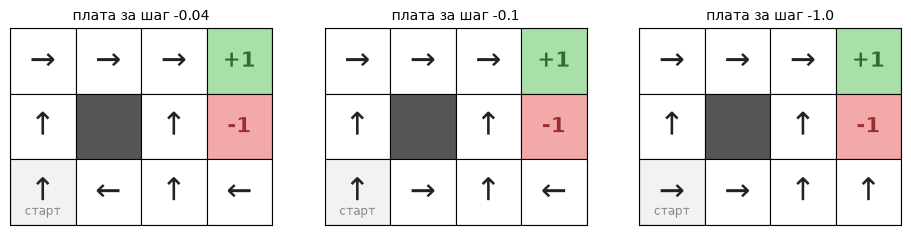

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(11.5, 3.4))
for ax, step_cost in zip(axes, [-0.04, -0.1, -1.0]):
    e = GridWorld(step_reward=step_cost)
    Pc, Rc = mdp_matrices(e)
    draw_policy(greedy_policy(solve_q_star(Pc, Rc)), e, ax=ax, title=f"плата за шаг {step_cost}")
plt.show()

При плате 0.04 за шаг агент терпелив: из клетки 9 идёт **влево**, длинным безопасным путём в обход ямы. При 0.1 он уже торопится и идёт **вправо**, вплотную под ямой, рискуя, что ветер его туда сдует. При 1.0 за шаг жизнь настолько дорога, что из клетки 11 агент лезет **вверх**, прямо к яме: −1 один раз лучше, чем десяток шагов по −1.

Все три стратегии оптимальны — каждая для своей задачи. Награда задаёт задачу, а уравнение находит ответ; на глаз такие переключения не угадываются.

## 5. Ещё один пример: Колобок и лотерея

Уравнение Беллмана — не про клетчатые миры, а про любую задачу, где решение сейчас влияет на будущее. Вот пример из учебника ШАД, где всего одно состояние.

Колобок Колабулька стоит у киоска и решает, покупать ли лотерейный билет. Билет стоит 10. С вероятностью $p$ он проигрышный, и Колобок снова оказывается у того же киоска перед тем же выбором. С вероятностью $1 - p$ билет выигрышный: приз 1000, и на этом всё заканчивается. Второе действие — «не покупать»: награда 0 и конец. Для простоты возьмём $\gamma = 1$.

![лотерея](https://raw.githubusercontent.com/IlyaChichkanov/Reinforcement-learning/main/assets/lottery_mdp.png)

Выпишем уравнение оптимальности для действия «купить» — по той же схеме, что и для клетки лабиринта: награда за шаг плюс среднее по исходам от «сколько лучшего можно набрать дальше».

$$
Q^*(\text{купить}) = -10 + p \cdot \max\big(Q^*(\text{купить}),\, 0\big) + (1 - p) \cdot 1000
$$

Максимум внутри — это выбор Колобка на следующем шаге: либо снова купить, либо уйти с нулём. Уравнение решается в уме. Если покупать выгодно, то есть $Q^* > 0$, максимум равен $Q^*$, и

$$
Q^* = -10 + p\,Q^* + 1000(1 - p) \quad\Longrightarrow\quad Q^* = 1000 - \frac{10}{1 - p}.
$$

Это положительно, пока $p < 0.99$. При $p \ge 0.99$ предположение неверно: покупать невыгодно, и $Q^* = -10 + 1000(1-p) \le 0$. Порог $p = 0.99$ — ровно честная игра: билет за 10 при выигрыше 1000 раз в сто.

Посчитаем то же самое кодом — **тем же циклом, что и на лабиринте**, только состояние теперь одно.

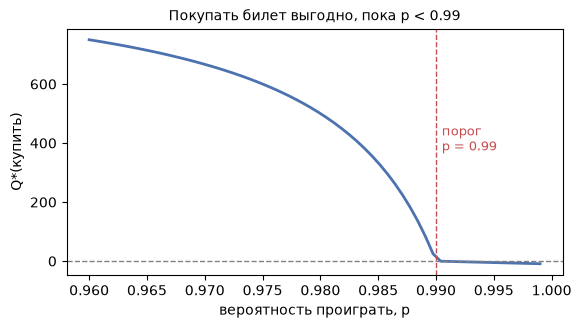

p = 0.98:  Q*(купить) =  +500.0   →  покупать
p = 0.99:  Q*(купить) =    +0.0   →  всё равно
p = 0.995:  Q*(купить) =    -5.0   →  не покупать


In [11]:
def lottery_q(p, cost=10, prize=1000, n_iter=500):
    """Уравнение оптимальности для «купить», решённое простой итерацией — как в разделе 4."""
    q = 0.0
    for _ in range(n_iter):
        q = -cost + p * max(q, 0) + (1 - p) * prize      # подставляем приближение в правую часть
    return q

ps = np.linspace(0.96, 0.999, 60)
values = [lottery_q(p) for p in ps]

plt.figure(figsize=(6.4, 3.2))
plt.plot(ps, values, lw=2, color="#4C72B0")
plt.axhline(0, color="grey", ls="--", lw=1)
plt.axvline(0.99, color="#C44E52", ls="--", lw=1)
plt.text(0.9905, max(values) * 0.5, "порог\np = 0.99", color="#C44E52", fontsize=9)
plt.xlabel("вероятность проиграть, p"); plt.ylabel("Q*(купить)")
plt.title("Покупать билет выгодно, пока p < 0.99", fontsize=10)
plt.show()

for p in (0.98, 0.99, 0.995):
    q = lottery_q(p)
    print(f"p = {p}:  Q*(купить) = {q:+7.1f}   →  " + ("покупать" if q > 1e-6 else "не покупать" if q < -1e-6 else "всё равно"))

Тот же цикл, та же логика — и содержательный ответ: до порога выгодно покупать билет за билетом, после порога лучше сразу уйти. Обратите внимание на сходство с лабиринтом: «купить» стоит −10 прямо сейчас, как шаг стоит −0.04, и оправдывает себя только через будущее.

## 6. Это называется MDP

Мы уже пользовались всеми составными частями задачи — пора назвать их по именам. Задача RL задаётся **марковским процессом принятия решений** (Markov Decision Process, MDP) — четвёркой $(\mathcal S, \mathcal A, p, r)$:

* $\mathcal S$ — множество **состояний** (у нас 12 клеток);
* $\mathcal A$ — множество **действий** (четыре направления);
* $p(s' \mid s, a)$ — **функция переходов**: с какой вероятностью среда перейдёт в $s'$, если в $s$ выбрать $a$ (у нас это ветер 0.8 / 0.1 / 0.1);
* $r$ — **функция награды** (−0.04 за шаг, ±1 в конце).

Агент действует по **стратегии** $\pi(a \mid s)$ — правилу, как выбирать действие; она может быть случайной. Взаимодействие порождает **траекторию** $s_0, a_0, r_0, s_1, a_1, r_1, \ldots$, а её кусок до терминального состояния — **эпизод**.

**Цель**: максимизировать среднюю суммарную награду, где награда через $t$ шагов умножается на $\gamma^t$ ($\gamma = 0.95$ у нас):

$$
J(\pi) = \mathbb E_{\tau \sim \pi} \Big[\, \sum_{t \ge 0} \gamma^t r_t \,\Big] \;\to\; \max_\pi
$$

Сумма под матожиданием — тот самый **return** $G_t$ из лекции 1. Дисконт $\gamma < 1$ нужен по трём причинам: сумма остаётся конечной даже в бесконечной задаче, агент предпочитает награду раньше («тортик сегодня лучше тортика завтра»), и, как мы видели, горизонт планирования становится конечным. У return есть свойство, из которого и вырос раздел 4: return с шага $t$ — это награда сейчас плюс дисконтированный return со следующего шага.

![return](https://raw.githubusercontent.com/IlyaChichkanov/Reinforcement-learning/main/assets/return_recursion.png)

В определении MDP спрятаны два предположения. **Марковость**: следующее состояние зависит только от текущего состояния и действия, а не от всей истории. Это требование не к миру, а к тому, что мы называем состоянием: одной фотографии летящего мяча мало, нужна ещё скорость. **Стационарность**: правила не меняются со временем. Если агент видит не всё состояние, а лишь его часть, говорят о частично наблюдаемой задаче (POMDP); на практике в наблюдение добавляют историю — например, DQN в Atari подаёт в сеть четыре последних кадра.

![наблюдение](https://raw.githubusercontent.com/IlyaChichkanov/Reinforcement-learning/main/assets/observation_vs_state.png)

Формализм общий: под него подходят и клетчатые миры, где все состояния можно перечислить (такие MDP называют **табличными**), и видеоигры, где состояние — картинка с экрана и таблицу уже не выписать, и управление роботом, где действия непрерывны. Разница только в том, помещается ли таблица в память и можно ли перебрать действия; математика раздела 4 одна и та же.

## 7. Как оценить стратегию и как её улучшить

Пока мы умели одно: найти **лучшую** стратегию, если известна модель. Но в работе чаще встречается другая ситуация: стратегия уже есть — написана руками, выучена вчера, досталась от коллеги. Про неё два вопроса:

* **насколько она хороша** — чтобы сравнить с другой и понять, стоит ли менять;
* **можно ли её быстро улучшить** — не начиная поиск заново.

Всё для ответа у нас уже есть: величины $V^\pi$ и $Q^\pi$ определены в разделе 3.1, а уравнение для них выведено в разделе 4 — той же подстановкой, что и уравнение оптимальности.

![два уравнения](https://raw.githubusercontent.com/IlyaChichkanov/Reinforcement-learning/main/assets/two_equations.png)

Напомним отличие: в уравнении оптимальности стоит $\max_a$ («дальше агент выберет лучшее»), в уравнении для стратегии — усреднение $\sum_a \pi(a \mid s)$ («дальше агент сделает то, что велит $\pi$»). В коде это отличие тоже ровно в одну строку.

📖 Для любителей матриц: без максимума уравнение линейно, $V^\pi = r_\pi + \gamma P_\pi V^\pi$, то есть $(I - \gamma P_\pi) V^\pi = r_\pi$, и решить его можно точно одной строкой `np.linalg.solve`. Мы посчитаем итерациями: ответ тот же до последнего знака, зато видно родство с разделом 4.

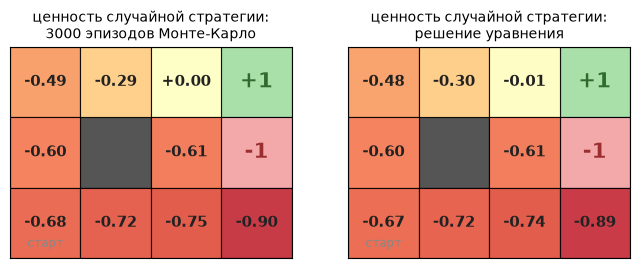

расхождение уравнения и Монте-Карло: 0.009


In [12]:
def evaluate_policy(policy, n_iter=300):
    """Ценность заданной стратегии: тот же цикл, что в разделе 4, только вместо max — среднее по π."""
    Q = np.zeros((env.n_states, env.n_actions))
    for _ in range(n_iter):
        V = (policy * Q).sum(axis=1)     # ← единственное отличие: в разделе 4 было V = Q.max(axis=1)
        Q = R + GAMMA * (P @ V)          # правая часть уравнения — строка из раздела 4 без изменений
    return Q, (policy * Q).sum(axis=1)

uniform = uniform_policy(env)                                   # стратегия «бросаю кубик»
Q_uniform, V_uniform = evaluate_policy(uniform)

rng = np.random.default_rng(1)
V_mc = estimate_values_mc([run_episode(env, uniform, rng) for _ in range(3000)], env.n_states)

fig, axes = plt.subplots(1, 2, figsize=(8, 3.6))
plot_values(V_mc, env, ax=axes[0], title="ценность случайной стратегии:\n3000 эпизодов Монте-Карло")
plot_values(V_uniform, env, ax=axes[1], title="ценность случайной стратегии:\nрешение уравнения")
plt.show()
print(f"расхождение уравнения и Монте-Карло: {np.nanmax(np.abs(V_uniform - V_mc)):.3f}")

Уравнение дало то, на что Монте-Карло потратил 3000 эпизодов, — и дало точно: левая карта шумит, правая нет. Заодно видно, насколько случайная стратегия плоха: ценность отрицательна **во всех** клетках, даже в соседней с выходом, а из старта она набирает −0.67 против +0.50 у оптимальной.

### 7.1 Один шаг улучшения

Теперь главное, ради чего всё считалось. У нас есть $Q^\pi$ — «сколько наберём, если сделать вот это действие, а дальше играть по старой стратегии». Построим новую стратегию: в каждой клетке выбираем действие с наибольшим $Q^\pi$. Звучит наивно, но результат гарантирован: **новая стратегия не хуже старой ни в одной клетке**.

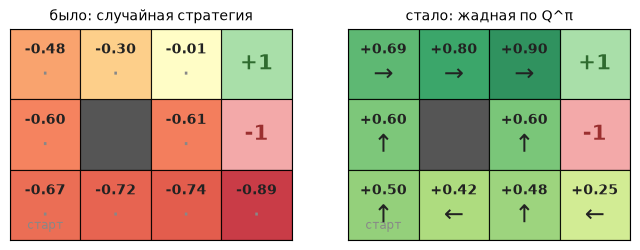

средний return: было -0.67, стало +0.50 (у оптимальной стратегии из раздела 4: +0.50)
ценность выросла во всех клетках: True


In [13]:
improved = greedy_policy(Q_uniform)                  # в каждой клетке пересаживаемся на лучшее действие по Q^π
Q_improved, V_improved = evaluate_policy(improved)

fig, axes = plt.subplots(1, 2, figsize=(8, 3.6))
draw_policy(uniform, env, ax=axes[0], values=V_uniform, title="было: случайная стратегия")
draw_policy(improved, env, ax=axes[1], values=V_improved, title="стало: жадная по Q^π")
plt.show()

print(f"средний return: было {average_return(env, uniform, np.random.default_rng(3), 500):+.2f}, "
      f"стало {average_return(env, improved, np.random.default_rng(3), 500):+.2f} "
      f"(у оптимальной стратегии из раздела 4: {average_return(env, greedy_policy(Q_star), np.random.default_rng(3), 500):+.2f})")
print("ценность выросла во всех клетках:", bool(np.all(V_improved >= V_uniform - 1e-9)))

Одна оценка и один жадный шаг превратили «бросаю кубик» в стратегию, которая на нашем маленьком мире уже оптимальна. В общем случае одного шага не хватает, и шаги повторяют: оценили — улучшили — снова оценили. Это **policy iteration**, его разберём на неделе 3.

![цикл](https://raw.githubusercontent.com/IlyaChichkanov/Reinforcement-learning/main/assets/policy_iteration_loop.png)

И ещё одно, забегая далеко вперёд: в глубоком RL по этому же уравнению учится «критик» в actor-critic (недели 8–9). Он оценивает текущую стратегию сети, а «актор» делает по его оценкам шаг улучшения — та же пара шагов, только вместо таблиц нейросети.

## 8. Итоги

1. **Ценность считается для стратегии.** $V^\pi(s)$ — сколько соберём из клетки $s$, играя по $\pi$; $Q^\pi(s, a)$ — то же с заданным первым действием. Оптимальные $Q^*$ и $V^*$ — это лучшее по всем стратегиям.
2. **$Q$ и $V$ выражаются друг через друга**, потому что ходы чередуются: в состоянии выбирает агент — усредняем по $\pi$, $V^\pi(s) = \sum_a \pi(a \mid s) Q^\pi(s, a)$; после действия выбирает среда — усредняем по исходам, $Q^\pi(s, a) = \sum_{s'} p\,[\,r + \gamma V^\pi(s')\,]$.
3. **Для оптимальной стратегии это частный случай:** жадная $\pi^*$ кладёт всю вероятность на лучшее действие, поэтому усреднение превращается в максимум, $V^*(s) = \max_a Q^*(s, a)$. Отсюда же и принцип оптимальности: из $Q^*$ стратегия получается сразу.
4. **Уравнение Беллмана — это подстановка одной связи в другую:** функция оказывается выражена через себя же. Для заданной $\pi$ получается уравнение с усреднением по $\pi$ (и оно линейно), для оптимальной — с максимумом. Неизвестное стоит по обе стороны, и решается это методом простой итерации — алгоритм value iteration.
5. **Всё это — про MDP** $(\mathcal S, \mathcal A, p, r)$ с марковским свойством и дисконтом $\gamma$; цель — максимум средней дисконтированной награды.
6. **Оценить можно любую стратегию**, а из оценки сразу получается стратегия получше: жадный шаг по $Q^\pi$ не ухудшает её ни в одной клетке. Повторяя «оценил — улучшил», приходим к оптимуму.

![карта](https://raw.githubusercontent.com/IlyaChichkanov/Reinforcement-learning/main/assets/bellman_family.png)

Главное ограничение сегодняшней лекции — мы всюду пользовались моделью среды, таблицами $p$ и $r$. В жизни их обычно нет: катаясь на велосипеде, вы не скажете, с какой вероятностью окажетесь через секунду в каждом из положений. На неделе 3 это ограничение снимается: матожидание в уравнении заменяют одним сыгранным переходом $(s, a, r, s')$, и получаются Monte-Carlo, TD-обучение, SARSA и Q-learning. Дальше меняется то, что ещё нельзя себе позволить: таблицу $Q$ заменяет нейросеть (DQN, неделя 6), перебор действий — отдельная сеть-актор (actor-critic, недели 8–9). Уравнение остаётся тем же.

Словарь лекции: **ценность действия $Q^\pi$, ценность состояния $V^\pi$, связь $V^\pi = \sum_a \pi Q^\pi$ и её частный случай $V^* = \max_a Q^*$, жадная стратегия, принцип оптимальности Беллмана, уравнение Беллмана, метод простой итерации, value iteration, MDP, функция переходов, стратегия, траектория, эпизод, дисконт, return, оценка стратегии $V^\pi$ и $Q^\pi$, шаг улучшения, policy iteration**.

## Литература

* [Учебник по машинному обучению ШАД, глава «Обучение с подкреплением»](https://education.yandex.ru/handbook/ml/article/obuchenie-s-podkrepleniem) — первоисточник сегодняшнего изложения, дальше там DQN и policy gradient.
* R. Sutton, A. Barto. *Reinforcement Learning: An Introduction* — [бесплатный PDF](http://incompleteideas.net/book/the-book-2nd.html). Глава 3 — MDP и уравнения Беллмана, глава 4 — динамическое программирование: оценка стратегии, policy iteration, value iteration.
* D. Silver. [UCL Course on RL](https://www.davidsilver.uk/teaching/), лекции 2 и 3.
* [Демонстрация value iteration в браузере](https://cs.stanford.edu/people/karpathy/reinforcejs/gridworld_dp.html) — тот же клетчатый мир, можно покрутить $\gamma$ и посмотреть, как меняются числа.

## На семинаре и дома

* **Семинар** (`../seminar/seminar.ipynb`): рисуем свой лабиринт, собираем для него модель среды, пишем одну итерацию уравнения, value iteration, оценку заданной стратегии и шаг улучшения — то же, что сегодня, но своими руками.
* **ДЗ** (`../homework/homework.ipynb`): среда «управление запасами», её модель из распределения спроса, оптимальная стратегия заказов из уравнения; теория — вывод уравнений Беллмана и лотерея Колобка.
* **Неделя 3**: те же уравнения, когда модель среды неизвестна — policy iteration, Monte-Carlo, TD-обучение, SARSA и Q-learning.